# 14 — PCA-Residual Feature Extraction

Remove tissue-of-origin confound from RNA and protein before feature selection.

**Plan:**
1. Scree plots → decide k (number of PCs to remove) together
2. Sanity checks on residual features
3. Re-run RF + encoder concat + cross-attention on residual features (fold 0)

All PCA fits are on **train-fold cell lines only** — no leakage into val/test.

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q rdkit torch-geometric
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/multiomics_project


In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr, spearmanr, linregress, f_oneway
from sklearn.metrics import r2_score, roc_auc_score
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

In [3]:
DATA_DIR      = BASE_PATH / 'data' / 'GDSC2'
PROCESSED_DIR = BASE_PATH / 'data' / 'processed'
SPLITS_DIR    = BASE_PATH / 'data' / 'splits'
RESULTS_DIR   = BASE_PATH / 'results' / 'pca_residual'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

COL_CELL_LINE   = 'cell_line_name'
COL_DRUG        = 'drug_name'
COL_IC50        = 'LN_IC50'
COL_CELLOSAURUS = 'cellosaurus_id'
COL_TISSUE      = 'tissue'

TOP_K_FEATURES = 1000
RANDOM_STATE   = 42
RF_PARAMS = dict(n_estimators=500, max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE)

## Load data

In [4]:
pairs = pd.read_parquet(PROCESSED_DIR / 'response_pairs.parquet')

with open(SPLITS_DIR / 'splits.json') as f:
    folds = json.load(f)

print(f'{len(pairs):,} pairs loaded')
for fd in folds:
    print(f"fold {fd['fold']}: train={len(fd['train']):,} | "
          f"lco={len(fd['lco_test']):,} | ldo={len(fd['ldo_test']):,} | "
          f"lto={len(fd['lto_test']):,} | lpo={len(fd['lpo_test']):,}")

176,197 pairs loaded
fold 0: train=107,421 | lco=17,470 | ldo=18,404 | lto=25,964 | lpo=20,613
fold 1: train=118,444 | lco=17,331 | ldo=18,515 | lto=13,579 | lpo=16,475
fold 2: train=97,262 | lco=18,173 | ldo=18,126 | lto=35,198 | lpo=23,832
fold 3: train=111,375 | lco=17,849 | ldo=18,140 | lto=21,451 | lpo=19,147
fold 4: train=103,126 | lco=17,762 | ldo=18,533 | lto=28,869 | lpo=21,721


In [5]:
rna     = pd.read_csv(DATA_DIR / 'gene_expression.csv',  index_col=0)
protein = pd.read_csv(DATA_DIR / 'proteomics.csv',       index_col=0)
drug_smiles = pd.read_csv(DATA_DIR / 'drug_smiles.csv')

rna     = rna[~rna.index.duplicated(keep='first')].iloc[:, 1:]
protein = protein[~protein.index.duplicated(keep='first')].fillna(0)

OMICS = {'rna': rna, 'protein': protein}

print(f'RNA:     {rna.shape[1]:,} genes    x {rna.shape[0]:,} cell lines')
print(f'Protein: {protein.shape[1]:,} proteins x {protein.shape[0]:,} cell lines')

RNA:     17,737 genes    x 1,010 cell lines
Protein: 6,692 proteins x 860 cell lines


In [6]:
def build_drug_fingerprints(drug_smiles_df, radius=2, n_bits=2048):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = {}
    for _, row in drug_smiles_df.iterrows():
        mol = Chem.MolFromSmiles(row['canonical_smiles'])
        if mol is None:
            continue
        fps[row[COL_DRUG]] = np.array(generator.GetFingerprint(mol), dtype=np.float32)
    return fps

drug_fp = build_drug_fingerprints(drug_smiles)
print(f'Fingerprints: {len(drug_fp):,} drugs')

Fingerprints: 246 drugs


## Evaluation metric (same as nb11)

In [7]:
def evaluateMT(target, pred):
    variance_pred = np.var(pred)
    mses = ((target - pred) ** 2).mean()
    rmse = np.sqrt(mses)
    pred_is_constant = np.isclose(variance_pred, 0)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        if pred_is_constant:
            correlation = spearman_corr = np.nan
        else:
            correlation, _ = pearsonr(target, pred)
            spearman_corr, _ = spearmanr(target, pred)

    r2 = r2_score(target, pred)
    return {
        'Pearson r': round(float(correlation), 4) if not np.isnan(correlation) else np.nan,
        'Spearman':  round(float(spearman_corr), 4) if not np.isnan(spearman_corr) else np.nan,
        'RMSE':      round(float(rmse), 4),
        'R2':        round(float(r2), 4),
    }

---
## Phase 1 — Scree plots and tissue-PC alignment

For each omics modality:
1. Fit PCA on train-fold cell lines (fold 0)
2. Plot cumulative variance explained → elbow tells us how many PCs capture tissue signal
3. Check how strongly top PCs correlate with tissue labels (F-statistic per PC)

**We pick k together after looking at the plots before writing any training code.**

### Fit PCA on fold 0 train cell lines

In [8]:
FOLD = 0
train_idx   = np.array(folds[FOLD]['train'])
train_cells = pairs.loc[train_idx, COL_CELLOSAURUS].unique()

print(f'Train cell lines (fold {FOLD}): {len(train_cells):,}')

rna_train     = rna.loc[rna.index.intersection(train_cells)]
protein_train = protein.loc[protein.index.intersection(train_cells)]

print(f'RNA train matrix:     {rna_train.shape}')
print(f'Protein train matrix: {protein_train.shape}')

Train cell lines (fold 0): 643
RNA train matrix:     (643, 17737)
Protein train matrix: (643, 6692)


In [9]:
# Fit PCA — keep enough components to see the full variance curve
# We'll use min(n_cells, n_features, 100) components to keep it fast
N_COMPONENTS = 50

pca_rna     = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca_protein = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)

pca_rna.fit(rna_train.values)
pca_protein.fit(protein_train.values)

print(f'RNA     PCA fit: {N_COMPONENTS} components on {rna_train.shape[0]} x {rna_train.shape[1]}')
print(f'Protein PCA fit: {N_COMPONENTS} components on {protein_train.shape[0]} x {protein_train.shape[1]}')

RNA     PCA fit: 50 components on 643 x 17737
Protein PCA fit: 50 components on 643 x 6692


### Scree plots — cumulative variance explained

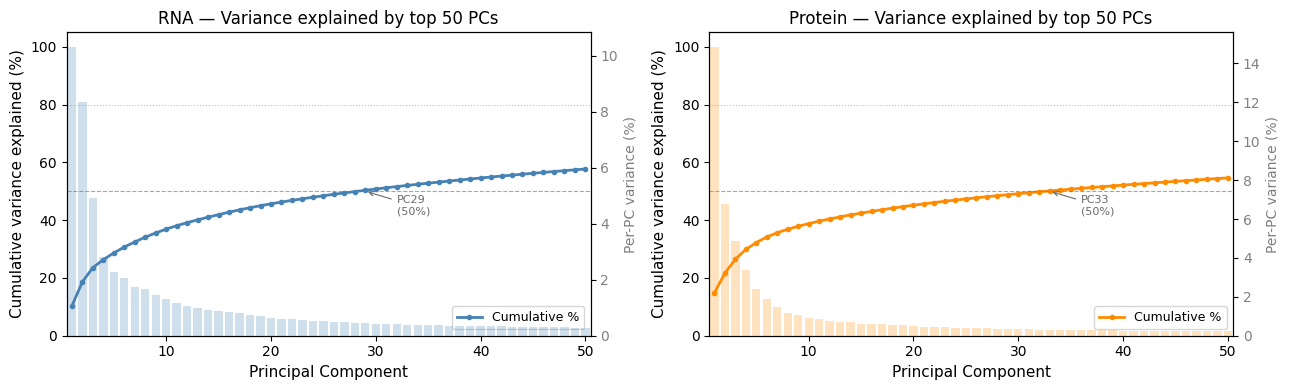

Saved: scree_plots.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, pca, label, color in zip(
    axes,
    [pca_rna, pca_protein],
    ['RNA', 'Protein'],
    ['steelblue', 'darkorange']
):
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    indvar = pca.explained_variance_ratio_ * 100

    ax2 = ax.twinx()
    ax2.bar(range(1, N_COMPONENTS + 1), indvar, alpha=0.25, color=color, label='Per-PC %')
    ax2.set_ylabel('Per-PC variance (%)', color='gray', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='gray')

    ax.plot(range(1, N_COMPONENTS + 1), cumvar, color=color, linewidth=2, marker='o',
            markersize=3, label='Cumulative %')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axhline(80, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Principal Component', fontsize=11)
    ax.set_ylabel('Cumulative variance explained (%)', fontsize=11)
    ax.set_title(f'{label} — Variance explained by top {N_COMPONENTS} PCs', fontsize=12)
    ax.set_xlim(0.5, N_COMPONENTS + 0.5)
    ax.set_ylim(0, 105)

    # annotate where we hit 50% and 80%
    for threshold in [50, 80]:
        hit = np.searchsorted(cumvar, threshold)
        if hit < N_COMPONENTS:
            ax.annotate(f'PC{hit+1}\n({threshold}%)',
                        xy=(hit + 1, threshold),
                        xytext=(hit + 4, threshold - 8),
                        fontsize=8, color='dimgray',
                        arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8))

    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'scree_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: scree_plots.png')

### Tissue-PC alignment — which PCs encode tissue-of-origin?

F-statistic per PC: how well does each PC separate tissue groups?
High F = that PC encodes tissue signal = candidate for removal.

In [11]:
# Project train cell lines into PC space
rna_pcs     = pca_rna.transform(rna_train.values)      # (n_train_cells, N_COMPONENTS)
protein_pcs = pca_protein.transform(protein_train.values)

# Get tissue labels for train cell lines
tissue_labels = (
    pairs.loc[train_idx, [COL_CELLOSAURUS, COL_TISSUE]]
    .drop_duplicates(subset=COL_CELLOSAURUS)
    .set_index(COL_CELLOSAURUS)[COL_TISSUE]
)

# Align to the rows in rna_train / protein_train
rna_tissues     = tissue_labels.reindex(rna_train.index).values
protein_tissues = tissue_labels.reindex(protein_train.index).values

print(f'Tissue groups (RNA train):     {len(np.unique(rna_tissues[rna_tissues != None])):,}')
print(f'Tissue groups (Protein train): {len(np.unique(protein_tissues[protein_tissues != None])):,}')

Tissue groups (RNA train):     23
Tissue groups (Protein train): 23


In [12]:
def tissue_f_stats(pcs: np.ndarray, tissue_labels: np.ndarray) -> np.ndarray:
    """One-way ANOVA F-statistic per PC — how much does tissue explain each PC?"""
    unique_tissues = np.unique(tissue_labels[~pd.isnull(tissue_labels)])
    f_stats = []
    for pc_i in range(pcs.shape[1]):
        groups = [pcs[tissue_labels == t, pc_i] for t in unique_tissues]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) < 2:
            f_stats.append(0.0)
        else:
            f, _ = f_oneway(*groups)
            f_stats.append(float(f) if not np.isnan(f) else 0.0)
    return np.array(f_stats)

f_rna     = tissue_f_stats(rna_pcs,     rna_tissues)
f_protein = tissue_f_stats(protein_pcs, protein_tissues)

print('Top 10 RNA PCs by tissue F-stat:')
for i in np.argsort(f_rna)[::-1][:10]:
    print(f'  PC{i+1:>2}: F={f_rna[i]:.1f}  |  cumvar={np.cumsum(pca_rna.explained_variance_ratio_)[i]*100:.1f}%')

print()
print('Top 10 Protein PCs by tissue F-stat:')
for i in np.argsort(f_protein)[::-1][:10]:
    print(f'  PC{i+1:>2}: F={f_protein[i]:.1f}  |  cumvar={np.cumsum(pca_protein.explained_variance_ratio_)[i]*100:.1f}%')

Top 10 RNA PCs by tissue F-stat:
  PC 3: F=93.0  |  cumvar=23.5%
  PC 2: F=48.5  |  cumvar=18.6%
  PC 9: F=46.7  |  cumvar=35.6%
  PC 6: F=32.2  |  cumvar=30.7%
  PC 4: F=30.8  |  cumvar=26.4%
  PC 7: F=30.2  |  cumvar=32.4%
  PC 1: F=27.5  |  cumvar=10.3%
  PC16: F=15.7  |  cumvar=42.8%
  PC10: F=15.7  |  cumvar=36.9%
  PC 8: F=14.2  |  cumvar=34.1%

Top 10 Protein PCs by tissue F-stat:
  PC 8: F=45.8  |  cumvar=36.8%
  PC 4: F=41.6  |  cumvar=29.9%
  PC10: F=26.2  |  cumvar=38.8%
  PC 2: F=25.1  |  cumvar=21.6%
  PC 9: F=22.0  |  cumvar=37.9%
  PC 3: F=21.2  |  cumvar=26.5%
  PC 6: F=19.8  |  cumvar=34.2%
  PC 1: F=18.2  |  cumvar=14.9%
  PC13: F=13.4  |  cumvar=41.1%
  PC12: F=13.1  |  cumvar=40.4%


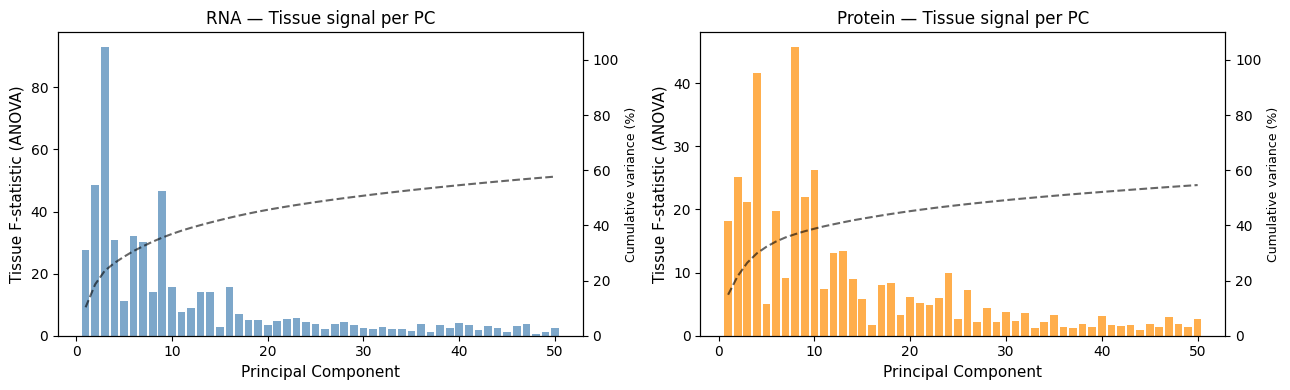

Saved: tissue_f_stats.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, f_stats, pca, label, color in zip(
    axes,
    [f_rna, f_protein],
    [pca_rna, pca_protein],
    ['RNA', 'Protein'],
    ['steelblue', 'darkorange']
):
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    pcs = np.arange(1, N_COMPONENTS + 1)

    ax.bar(pcs, f_stats, color=color, alpha=0.7)
    ax.set_xlabel('Principal Component', fontsize=11)
    ax.set_ylabel('Tissue F-statistic (ANOVA)', fontsize=11)
    ax.set_title(f'{label} — Tissue signal per PC', fontsize=12)

    # overlay cumulative variance as a line on twin axis
    ax2 = ax.twinx()
    ax2.plot(pcs, cumvar, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    ax2.set_ylabel('Cumulative variance (%)', color='black', fontsize=9)
    ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tissue_f_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tissue_f_stats.png')

**↑ Look at these two plots before continuing.**

Decide k for RNA and k for protein:
- Look for where the F-statistic drops sharply (PCs after that carry less tissue signal)
- Cross-reference with the scree plot (don't remove PCs that carry <1% variance each — diminishing returns)
- Typical expectation: k=10–30 for RNA, possibly smaller for protein

Set `K_RNA` and `K_PROTEIN` in the next cell, then proceed to Phase 2.

---
## Phase 2 — Sanity checks on residual features

**Set k values here based on the plots above, then run Phase 2.**

In [14]:
# ── SET THESE BASED ON SCREE + F-STAT PLOTS ───────────────────────────────────
K_RNA     = 10   # number of top PCs to remove from RNA
K_PROTEIN = 15   # number of top PCs to remove from protein
# ─────────────────────────────────────────────────────────────────────────────

print(f'Removing top {K_RNA} PCs from RNA, top {K_PROTEIN} PCs from protein')
print('Adjust K_RNA and K_PROTEIN above if the plots suggest different values.')

Removing top 10 PCs from RNA, top 15 PCs from protein
Adjust K_RNA and K_PROTEIN above if the plots suggest different values.


### PCA-residual computation (fold-safe)

In [15]:
def fit_pca_residual(train_cells: np.ndarray, omics_df: pd.DataFrame, k: int) -> PCA:
    """Fit PCA on train cell lines only. Returns fitted PCA object."""
    sub = omics_df.loc[omics_df.index.intersection(train_cells)]
    pca = PCA(n_components=k, random_state=RANDOM_STATE)
    pca.fit(sub.values)
    return pca


def compute_residuals(omics_df: pd.DataFrame, cell_ids: np.ndarray, pca: PCA) -> np.ndarray:
    """
    Project cell lines into PCA space and subtract reconstruction.
    residual = original - (scores @ components + mean)
    Returns (n_cells, n_features) float32 array.
    Cell lines not in omics_df index are filled with zeros.
    """
    available = omics_df.index.intersection(cell_ids)
    X = omics_df.loc[available].values.astype(np.float64)

    scores = pca.transform(X)                    # (n_cells, k)
    reconstruction = pca.inverse_transform(scores)  # (n_cells, n_features)
    residuals = X - reconstruction               # (n_cells, n_features)

    # Put back into order matching cell_ids, filling missing with 0
    result = np.zeros((len(cell_ids), omics_df.shape[1]), dtype=np.float32)
    idx_map = {cid: i for i, cid in enumerate(cell_ids)}
    for j, cid in enumerate(available):
        result[idx_map[cid]] = residuals[j]

    return result

In [16]:
# Fit on fold 0 train cell lines only
pca_rna_k     = fit_pca_residual(train_cells, rna,     K_RNA)
pca_protein_k = fit_pca_residual(train_cells, protein, K_PROTEIN)

print(f'RNA PCA ({K_RNA} components): '
      f'{np.cumsum(pca_rna_k.explained_variance_ratio_)[-1]*100:.1f}% variance captured (removed)')
print(f'Protein PCA ({K_PROTEIN} components): '
      f'{np.cumsum(pca_protein_k.explained_variance_ratio_)[-1]*100:.1f}% variance captured (removed)')

RNA PCA (10 components): 36.9% variance captured (removed)
Protein PCA (15 components): 42.4% variance captured (removed)


In [17]:
# Compute residuals for all split cell lines (using train-fitted PCAs)
def get_split_cells(split_key: str) -> np.ndarray:
    idx = np.array(folds[FOLD][split_key])
    return pairs.loc[idx, COL_CELLOSAURUS].unique()

lco_cells = get_split_cells('lco_test')
ldo_cells = get_split_cells('ldo_test')
lpo_cells = get_split_cells('lpo_test')
lto_cells = get_split_cells('lto_test')

# Build per-cell-line residual matrices (used for lookup during RF)
residuals = {}
for split_name, cells in [
    ('train', train_cells),
    ('lco',   lco_cells),
    ('ldo',   ldo_cells),
    ('lpo',   lpo_cells),
    ('lto',   lto_cells),
]:
    residuals[f'rna_{split_name}']     = compute_residuals(rna,     cells, pca_rna_k)
    residuals[f'protein_{split_name}'] = compute_residuals(protein, cells, pca_protein_k)
    print(f'{split_name:6s}: rna_residual={residuals[f"rna_{split_name}"].shape}  '
          f'protein_residual={residuals[f"protein_{split_name}"].shape}')

train : rna_residual=(643, 17737)  protein_residual=(643, 6692)
lco   : rna_residual=(84, 17737)  protein_residual=(84, 6692)
ldo   : rna_residual=(835, 17737)  protein_residual=(835, 6692)
lpo   : rna_residual=(836, 17737)  protein_residual=(836, 6692)
lto   : rna_residual=(123, 17737)  protein_residual=(123, 6692)


### Sanity check 1 — RNA-protein cross-cell-line correlation

Baseline confound diagnostic: with top-variance features, RNA and protein predictions
correlate at r=0.996. After residual removal, this should drop substantially.

We check this directly: for each cell line in train, compute the mean of its
rna-residual and protein-residual vectors, then correlate across cell lines.
(Same diagnostic as the earlier per-cell-line correlation analysis.)

In [18]:
# Per-cell-line mean feature value — captures how similar RNA and protein are across cells
rna_cell_means     = residuals['rna_train'].mean(axis=1)
protein_cell_means = residuals['protein_train'].mean(axis=1)

r_after, _ = pearsonr(rna_cell_means, protein_cell_means)

# Compare to top-variance baseline (recompute for reference)
top_rna_cols = rna.loc[rna.index.intersection(train_cells)].var(axis=0).sort_values(ascending=False).index[:TOP_K_FEATURES]
top_prot_cols = protein.loc[protein.index.intersection(train_cells)].var(axis=0).sort_values(ascending=False).index[:TOP_K_FEATURES]

rna_tv_means     = rna.loc[rna.index.intersection(train_cells), top_rna_cols].mean(axis=1)
protein_tv_means = protein.loc[protein.index.intersection(train_cells), top_prot_cols].mean(axis=1)

# Align indices
common_cells = rna_tv_means.index.intersection(protein_tv_means.index)
r_before, _ = pearsonr(rna_tv_means.loc[common_cells], protein_tv_means.loc[common_cells])

print('Cross-cell-line RNA-protein correlation:')
print(f'  Top-variance features (baseline): r = {r_before:.4f}')
print(f'  PCA-residual features (nb14):     r = {r_after:.4f}')
print()
if abs(r_after) < 0.5:
    print('✓  Tissue confound substantially reduced')
elif abs(r_after) < abs(r_before) * 0.7:
    print('~  Partial reduction — may want to increase K_RNA / K_PROTEIN')
else:
    print('✗  Confound not reduced — check K values or PCA fit')

Cross-cell-line RNA-protein correlation:
  Top-variance features (baseline): r = 0.5244
  PCA-residual features (nb14):     r = 0.0414

✓  Tissue confound substantially reduced


In [19]:
def select_top_residual_cols(residual_matrix: np.ndarray, k: int = TOP_K_FEATURES) -> np.ndarray:
    """Top-k columns by variance across train cell lines, computed on the residual matrix."""
    variances = residual_matrix.var(axis=0)
    return np.argsort(variances)[::-1][:k]

top_residual_cols = {
    'rna':     select_top_residual_cols(residuals['rna_train']),
    'protein': select_top_residual_cols(residuals['protein_train']),
}

print(f"Selected {len(top_residual_cols['rna'])} RNA residual columns")
print(f"Selected {len(top_residual_cols['protein'])} protein residual columns")

Selected 1000 RNA residual columns
Selected 1000 protein residual columns


In [29]:
# Mean of selected residual columns per cell line — same diagnostic as sanity check 1
rna_selected_means     = residuals['rna_train'][:, top_residual_cols['rna']].mean(axis=1)
protein_selected_means = residuals['protein_train'][:, top_residual_cols['protein']].mean(axis=1)

r_selected, _ = pearsonr(rna_selected_means, protein_selected_means)

print(f'Cross-cell-line correlation after top-k residual selection:')
print(f'  All residual columns (sanity check 1): r = 0.0414')
print(f'  Top-{TOP_K_FEATURES} residual columns:            r = {r_selected:.4f}')
print()
if abs(r_selected) < 0.2:
    print('✓  Selected features remain independent')
elif abs(r_selected) < 0.5:
    print('~  Some correlation reintroduced — top-variance selection may be re-picking shared axes')
else:
    print('✗  High correlation — top-variance selection is reintroducing tissue signal')
    print('   Consider using random column selection or reducing k')

Cross-cell-line correlation after top-k residual selection:
  All residual columns (sanity check 1): r = 0.0414
  Top-1000 residual columns:            r = 0.4866

~  Some correlation reintroduced — top-variance selection may be re-picking shared axes


In [30]:
# Are the top-1000 residual columns themselves overlapping between RNA and protein?
# (only meaningful if RNA and protein share gene-symbol column names)
rna_col_names  = rna.columns[top_residual_cols['rna']]
prot_col_names = protein.columns[top_residual_cols['protein']]
overlap = rna_col_names.intersection(prot_col_names)
print(f'Column name overlap between top-1000 RNA and protein residual cols: {len(overlap)}')

Column name overlap between top-1000 RNA and protein residual cols: 0


In [34]:
def select_by_ic50_correlation(
    residual_matrix: np.ndarray,
    cell_ids: np.ndarray,
    train_idx: np.ndarray,
    k: int = TOP_K_FEATURES,
) -> np.ndarray:
    """
    Select top-k columns by mean absolute correlation with IC50 across drugs.
    Computed on train pairs only — fold-safe.
    Uses mean |r| across the 20 most-tested drugs to avoid single-drug bias.
    """
    train_pairs = pairs.loc[train_idx]
    cell_to_row = {c: i for i, c in enumerate(cell_ids)}

    # Top 20 drugs by number of train measurements — representative sample
    top_drugs = train_pairs[COL_DRUG].value_counts().index[:20]

    col_cors = np.zeros(residual_matrix.shape[1])

    for drug in top_drugs:
        drug_pairs = train_pairs[train_pairs[COL_DRUG] == drug]
        rows = np.array([cell_to_row[c] for c in drug_pairs[COL_CELLOSAURUS]
                         if c in cell_to_row])
        if len(rows) < 10:
            continue
        y = drug_pairs.loc[
            drug_pairs[COL_CELLOSAURUS].isin(cell_to_row), COL_IC50
        ].values.astype(np.float32)
        X_drug = residual_matrix[rows]  # (n_cells_for_drug, n_features)

        # Vectorised correlation: each column vs y
        X_c = X_drug - X_drug.mean(axis=0)
        y_c = y - y.mean()
        denom = np.sqrt((X_c ** 2).sum(axis=0)) * np.sqrt((y_c ** 2).sum())
        with np.errstate(invalid='ignore', divide='ignore'):
            cors = np.where(denom > 0, (X_c * y_c[:, None]).sum(axis=0) / denom, 0.0)
        col_cors += np.abs(cors)

    col_cors /= len(top_drugs)
    return np.argsort(col_cors)[::-1][:k]


top_residual_cols = {
    'rna':     select_by_ic50_correlation(residuals['rna_train'],     train_cells, train_idx),
    'protein': select_by_ic50_correlation(residuals['protein_train'], train_cells, train_idx),
}

print(f"Selected {len(top_residual_cols['rna'])} RNA columns by IC50 correlation")
print(f"Selected {len(top_residual_cols['protein'])} protein columns by IC50 correlation")

Selected 1000 RNA columns by IC50 correlation
Selected 1000 protein columns by IC50 correlation


In [35]:
rna_selected_means     = residuals['rna_train'][:, top_residual_cols['rna']].mean(axis=1)
protein_selected_means = residuals['protein_train'][:, top_residual_cols['protein']].mean(axis=1)
r_selected, _ = pearsonr(rna_selected_means, protein_selected_means)
print(f'Cross-cell-line correlation (IC50-selected residual cols): r = {r_selected:.4f}')

Cross-cell-line correlation (IC50-selected residual cols): r = -0.0345


### Sanity check 2 — RF on residual features still beats naive mean

If residuals carry zero drug-response signal, the tissue confound has completely
swamped the useful variance. We need at least some predictive signal to remain.

In [21]:
# Reindex residual matrices with the actual split cell lists for lookup
# (overwrite split_cells_list logic with a cleaner precomputed index)
SPLIT_CELL_INDEX = {
    'train': {c: i for i, c in enumerate(train_cells)},
    'lco':   {c: i for i, c in enumerate(lco_cells)},
    'ldo':   {c: i for i, c in enumerate(ldo_cells)},
    'lpo':   {c: i for i, c in enumerate(lpo_cells)},
    'lto':   {c: i for i, c in enumerate(lto_cells)},
}

def build_rf_residual_matrix(idx: np.ndarray, split_name: str, components: list) -> tuple:
    """Build feature matrix using top-k PCA-residual omics + raw drug fingerprints."""
    sub   = pairs.loc[idx]
    cells = sub[COL_CELLOSAURUS].values
    cell_to_row = SPLIT_CELL_INDEX[split_name]

    parts = []
    if 'rna' in components:
        rna_res  = residuals[f'rna_{split_name}']
        rna_rows = np.array([cell_to_row[c] for c in cells])
        parts.append(rna_res[rna_rows][:, top_residual_cols['rna']])
    if 'protein' in components:
        prot_res  = residuals[f'protein_{split_name}']
        prot_rows = np.array([cell_to_row[c] for c in cells])
        parts.append(prot_res[prot_rows][:, top_residual_cols['protein']])
    if 'drug' in components:
        parts.append(np.vstack([drug_fp[d] for d in sub[COL_DRUG]]))

    X = np.hstack(parts).astype(np.float32)
    y = sub[COL_IC50].to_numpy().astype(np.float32)
    assert not np.isnan(X).any(), 'NaNs in X'
    assert not np.isnan(y).any(), 'NaNs in y'
    return X, y

In [22]:
# Quick RF smoke test: RNA-residual + drug on fold 0 LCO
# Should beat naive mean (LCO ~0.22 with top-variance RNA-only, naive mean ~0.0)

train_idx = np.array(folds[FOLD]['train'])
lco_idx   = np.array(folds[FOLD]['lco_test'])

X_train, y_train = build_rf_residual_matrix(train_idx, 'train', ['rna', 'drug'])
X_lco,   y_lco   = build_rf_residual_matrix(lco_idx,   'lco',   ['rna', 'drug'])
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')

print(f'RF smoke test: RNA-residual + drug on fold {FOLD} LCO')
rf_smoke = RandomForestRegressor(**RF_PARAMS)
rf_smoke.fit(X_train, y_train)
y_pred_lco = rf_smoke.predict(X_lco)

metrics = evaluateMT(y_lco, y_pred_lco)
naive_mean = np.full_like(y_lco, y_train.mean())
naive_metrics = evaluateMT(y_lco, naive_mean)

print('Sanity check 2 — RF (RNA-residual + drug) vs naive mean on LCO:')
print(f'  Naive mean:        Pearson r = {naive_metrics["Pearson r"]}')
print(f'  RF RNA-residual:   Pearson r = {metrics["Pearson r"]}')
print()
if metrics['Pearson r'] > naive_metrics['Pearson r']:
    print('✓  Residual features retain predictive signal')
else:
    print('✗  Residual features lost all signal — consider reducing K_RNA')

X_train: (107421, 3048), y_train: (107421,)
RF smoke test: RNA-residual + drug on fold 0 LCO
Sanity check 2 — RF (RNA-residual + drug) vs naive mean on LCO:
  Naive mean:        Pearson r = nan
  RF RNA-residual:   Pearson r = 0.8288

✗  Residual features lost all signal — consider reducing K_RNA


### Sanity check 3 — RNA and protein residuals diverge in performance

With top-variance features, RF(RNA+drug) and RF(protein+drug) gave nearly identical
LCO scores (~0.22), confirming they carry the same tissue signal.
After residual removal, the two modalities should diverge.

In [23]:
X_train_prot, _ = build_rf_residual_matrix(train_idx, 'train', ['protein', 'drug'])
X_lco_prot, _   = build_rf_residual_matrix(lco_idx,   'lco',   ['protein', 'drug'])
print(f'X_train_prot: {X_train_prot.shape}, X_lco_prot: {X_lco_prot.shape}')

rf_protein = RandomForestRegressor(**RF_PARAMS)
print('Starting RF training on protein-residual + drug...')
rf_protein.fit(X_train_prot, y_train)
print('RF training complete.')
y_pred_prot = rf_protein.predict(X_lco_prot)
metrics_prot = evaluateMT(y_lco, y_pred_prot)

print('Sanity check 3 — LCO Pearson r after residual removal:')
print(f'  RF RNA-residual + drug:     {metrics["Pearson r"]}')
print(f'  RF Protein-residual + drug: {metrics_prot["Pearson r"]}')
print()
diff = abs(metrics['Pearson r'] - metrics_prot['Pearson r'])
if diff > 0.03:
    print(f'✓  Modalities diverged by {diff:.4f} — tissue confound reduced')
else:
    print(f'~  Modalities still similar (diff={diff:.4f}) — confound may persist')
    print('   Consider increasing K_RNA or K_PROTEIN')

X_train_prot: (107421, 3048), X_lco_prot: (17470, 3048)
Starting RF training on protein-residual + drug...
RF training complete.
Sanity check 3 — LCO Pearson r after residual removal:
  RF RNA-residual + drug:     0.8288
  RF Protein-residual + drug: 0.8288

~  Modalities still similar (diff=0.0000) — confound may persist
   Consider increasing K_RNA or K_PROTEIN


---
## Phase 3 — Re-run key models on residual features

**Only proceed here if all three sanity checks passed.**

Three arms, fold 0 only, all four test splits (LCO, LDO, LTO, LPO):
1. RF: RNA-residual + drug, Protein-residual + drug, Both + drug
2. Encoder concat (rna_enc + protein_enc + drug_enc) — from nb12 Tier 2
3. Cross-attention (AX fp+attn) — from nb13

Results are directly comparable to nb12/13 fold 0 numbers.

### RF arms — residual features

In [36]:
import time

SPLIT_TYPES = ['lco', 'ldo', 'lto', 'lpo']

def run_rf_residual_arm(arm_name: str, components: list) -> list:
    """Run RF for one arm on fold 0 across all 4 test splits."""
    results = []
    start = time.time()

    X_tr, y_tr = build_rf_residual_matrix(train_idx, 'train', components)
    print(f'[{arm_name}] Training RF on {X_tr.shape[0]:,} samples with {X_tr.shape[1]:,} features...')
    
    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(X_tr, y_tr)

    for split_type in SPLIT_TYPES:
        test_idx = np.array(folds[FOLD][f'{split_type}_test'])
        X_te, y_te = build_rf_residual_matrix(test_idx, split_type, components)
        y_pred = model.predict(X_te)
        m = evaluateMT(y_te, y_pred)
        m.update({'Arm': arm_name, 'Split': split_type.upper(), 'Fold': FOLD})
        results.append(m)

    elapsed = time.time() - start
    lco_r = next(r['Pearson r'] for r in results if r['Split'] == 'LCO')
    ldo_r = next(r['Pearson r'] for r in results if r['Split'] == 'LDO')
    print(f'[{arm_name}] LCO={lco_r:.4f}  LDO={ldo_r:.4f}  ({elapsed:.1f}s)')
    return results

rf_results = []

In [37]:
# RNA-residual + drug
rf_results += run_rf_residual_arm('RF rna_residual+drug', ['rna', 'drug'])

[RF rna_residual+drug] Training RF on 107,421 samples with 3,048 features...
[RF rna_residual+drug] LCO=0.8247  LDO=0.3034  (538.6s)


In [38]:
# Protein-residual + drug
rf_results += run_rf_residual_arm('RF protein_residual+drug', ['protein', 'drug'])

[RF protein_residual+drug] Training RF on 107,421 samples with 3,048 features...
[RF protein_residual+drug] LCO=0.8357  LDO=0.3283  (521.5s)


In [39]:
# Both residuals + drug
rf_results += run_rf_residual_arm('RF rna_residual+protein_residual+drug', ['rna', 'protein', 'drug'])

[RF rna_residual+protein_residual+drug] Training RF on 107,421 samples with 4,048 features...
[RF rna_residual+protein_residual+drug] LCO=0.8340  LDO=0.3084  (741.6s)


In [40]:
rf_df = pd.DataFrame(rf_results)[['Arm', 'Fold', 'Split', 'Pearson r', 'Spearman', 'RMSE', 'R2']]
display(rf_df.sort_values(['Arm', 'Split']))
rf_df.to_csv(RESULTS_DIR / 'rf_residual_results.csv', index=False)
print('Saved: rf_residual_results.csv')

,Arm,Fold,Split,Pearson r,Spearman,RMSE,R2
4,RF protein_residual+drug,0,LCO,0.8357,0.7899,1.4771,0.6955
5,RF protein_residual+drug,0,LDO,0.3283,0.3509,2.4191,0.1024
7,RF protein_residual+drug,0,LPO,0.8614,0.8295,1.3776,0.7389
6,RF protein_residual+drug,0,LTO,0.8479,0.8072,1.4934,0.7044
0,RF rna_residual+drug,0,LCO,0.8247,0.7788,1.5225,0.6765
1,RF rna_residual+drug,0,LDO,0.3034,0.3256,2.4408,0.0863
3,RF rna_residual+drug,0,LPO,0.8553,0.8247,1.4085,0.7271
2,RF rna_residual+drug,0,LTO,0.8399,0.7978,1.5850,0.6670
8,RF rna_residual+protein_residual+drug,0,LCO,0.8340,0.7887,1.4835,0.6928
9,RF rna_residual+protein_residual+drug,0,LDO,0.3084,0.3396,2.4375,0.0888


Saved: rf_residual_results.csv


---
### DL arm — Encoder concat (rna_enc + protein_enc + drug_enc)

Replicates nb12 Tier 2 arm 7 on PCA-residual features.
Input to each OmicsEncoder: TOP_K_FEATURES=1000 IC50-selected residual columns.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cpu':
    print('WARNING: no GPU — Runtime > Change runtime type > GPU')

In [44]:
EMBED_DIM    = 256
HIDDEN_DIM   = 512
DROPOUT      = 0.3
BATCH_SIZE   = 512
NUM_EPOCHS   = 20
PATIENCE     = 5
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DRUG_DIM     = 2048
RNA_DIM      = TOP_K_FEATURES   # 1000 IC50-selected residual columns
PROTEIN_DIM  = TOP_K_FEATURES

In [45]:
def make_validation_indices(train_idx, fraction=0.1, seed=RANDOM_STATE):
    """Hold out a fraction of cell lines, drugs, and tissues — identical to nb12."""
    sub = pairs.loc[train_idx]

    def axis_holdout(group_values, seed_offset):
        gss = GroupShuffleSplit(n_splits=1, test_size=fraction,
                                random_state=seed + seed_offset)
        _, val_idx = next(gss.split(range(len(group_values)), groups=group_values))
        return set(group_values.iloc[val_idx])

    cell_ho   = axis_holdout(sub[COL_CELLOSAURUS], 0)
    drug_ho   = axis_holdout(sub[COL_DRUG],        1)
    tissue_ho = axis_holdout(sub[COL_TISSUE],      2)

    is_val = (
        sub[COL_CELLOSAURUS].isin(cell_ho)
        | sub[COL_DRUG].isin(drug_ho)
        | sub[COL_TISSUE].isin(tissue_ho)
    ).to_numpy()

    return train_idx[~is_val], train_idx[is_val]

train_inner_idx, val_idx_dl = make_validation_indices(train_idx)
print(f'train_inner: {len(train_inner_idx):,} | val: {len(val_idx_dl):,}')

train_inner: 79,187 | val: 28,234


In [46]:
def build_dl_tensors(idx: np.ndarray, split_name: str) -> dict:
    """Tensors from IC50-selected PCA-residual columns + drug fingerprint."""
    sub       = pairs.loc[idx]
    cells     = sub[COL_CELLOSAURUS].values
    cell_to_row = SPLIT_CELL_INDEX[split_name]

    rows      = np.array([cell_to_row[c] for c in cells])
    rna_X     = residuals[f'rna_{split_name}'][rows][:, top_residual_cols['rna']]
    protein_X = residuals[f'protein_{split_name}'][rows][:, top_residual_cols['protein']]
    drug_X    = np.vstack([drug_fp[d] for d in sub[COL_DRUG]]).astype(np.float32)
    y         = sub[COL_IC50].to_numpy().astype(np.float32)

    return {
        'rna':     torch.from_numpy(rna_X),
        'protein': torch.from_numpy(protein_X),
        'drug':    torch.from_numpy(drug_X),
        'y':       torch.from_numpy(y),
    }

def make_loader(tensors: dict, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(tensors['rna'], tensors['protein'],
                       tensors['drug'], tensors['y'])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)

print('Building tensors...')
train_tensors = build_dl_tensors(train_inner_idx, 'train')
val_tensors   = build_dl_tensors(val_idx_dl,      'train')
print(f"train rna={train_tensors['rna'].shape}  protein={train_tensors['protein'].shape}")
print(f"val   rna={val_tensors['rna'].shape}")

Building tensors...
train rna=torch.Size([79187, 1000])  protein=torch.Size([79187, 1000])
val   rna=torch.Size([28234, 1000])


In [54]:
class OmicsEncoder(nn.Module):
    def __init__(self, in_dim, hidden=HIDDEN_DIM, out_dim=EMBED_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
        )
    def forward(self, x): return self.net(x)


class EncoderConcatModel(nn.Module):
    """rna_enc + protein_enc + drug_enc → concat → MLP → IC50 (nb12 Tier 2 arm 7)."""
    def __init__(self, rna_dim, protein_dim, drug_dim=DRUG_DIM,
                 embed_dim=EMBED_DIM, dropout=DROPOUT):
        super().__init__()
        self.rna_enc     = OmicsEncoder(rna_dim,     out_dim=embed_dim, dropout=dropout)
        self.protein_enc = OmicsEncoder(protein_dim, out_dim=embed_dim, dropout=dropout)
        self.drug_enc    = OmicsEncoder(drug_dim,    out_dim=embed_dim, dropout=dropout)
        self.predictor   = nn.Sequential(
            nn.Linear(embed_dim * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
    def forward(self, rna, protein, drug):
        x = torch.cat([self.rna_enc(rna),
                        self.protein_enc(protein),
                        self.drug_enc(drug)], dim=1)
        return self.predictor(x).squeeze(-1)


enc_concat_model = EncoderConcatModel(RNA_DIM, PROTEIN_DIM).to(DEVICE)
n_params = sum(p.numel() for p in enc_concat_model.parameters() if p.requires_grad)
print(f'EncoderConcatModel: {n_params:,} parameters')

EncoderConcatModel: 2,933,249 parameters


In [55]:
def train_model(model, train_tensors, val_tensors,
                num_epochs=NUM_EPOCHS, patience=PATIENCE,
                checkpoint_path=None, device=DEVICE):
    """Generic training loop with early stopping — reused for both arms."""
    train_loader = make_loader(train_tensors, BATCH_SIZE, shuffle=True)
    val_loader   = make_loader(val_tensors,   BATCH_SIZE, shuffle=False)
    criterion    = nn.HuberLoss()
    optimizer    = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_loss, best_weights, wait = float('inf'), None, 0

    for epoch in range(num_epochs):
        # ── train ──
        model.to(device).train()
        for rna_b, prot_b, drug_b, y_b in train_loader:
            rna_b, prot_b, drug_b, y_b = (t.to(device) for t in (rna_b, prot_b, drug_b, y_b))
            optimizer.zero_grad()
            nn.HuberLoss()(model(rna_b, prot_b, drug_b), y_b).backward()
            optimizer.step()

        # ── val ──
        model.to('cpu').eval()
        val_losses, preds, targets = [], [], []
        with torch.no_grad():
            for rna_b, prot_b, drug_b, y_b in val_loader:
                pred = model(rna_b, prot_b, drug_b)
                val_losses.append(criterion(pred, y_b).item())
                preds.append(pred); targets.append(y_b)

        val_loss = sum(val_losses) / len(val_losses)
        val_r, _ = pearsonr(torch.cat(targets).numpy(), torch.cat(preds).numpy())

        if (epoch + 1) % 10 == 0:
            print(f'  epoch {epoch+1:>3} | val loss={val_loss:.4f}  pearson_r={val_r:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)
    if checkpoint_path:
        checkpoint_path.parent.mkdir(exist_ok=True)
        torch.save(best_weights, checkpoint_path)
    return model


def predict_model(model, tensors, batch_size=512):
    model.to('cpu').eval()
    loader = make_loader(tensors, batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for rna_b, prot_b, drug_b, _ in loader:
            preds.append(model(rna_b, prot_b, drug_b))
    return torch.cat(preds).numpy()


def eval_all_splits(model, arm_name, split_types=SPLIT_TYPES):
    results = []
    for split_type in split_types:
        test_idx     = np.array(folds[FOLD][f'{split_type}_test'])
        test_tensors = build_dl_tensors(test_idx, split_type)
        y_pred = predict_model(model, test_tensors)
        y_true = test_tensors['y'].numpy()
        m = evaluateMT(y_true, y_pred)
        m.update({'Arm': arm_name, 'Split': split_type.upper(), 'Fold': FOLD})
        results.append(m)
        print(f'  {split_type.upper():4s}: Pearson r={m["Pearson r"]:.4f}  RMSE={m["RMSE"]:.4f}')
    return results

In [56]:
print('Training EncoderConcat on PCA-residual features...')
enc_concat_model = train_model(
    enc_concat_model, train_tensors, val_tensors,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'enc_concat_residual_fold0.pt',
)
print()
print('EncoderConcat results:')
enc_concat_results = eval_all_splits(enc_concat_model, 'enc_concat_residual')

Training EncoderConcat on PCA-residual features...
  epoch  10 | val loss=0.9680  pearson_r=0.6926
  Early stopping at epoch 19

EncoderConcat results:
  LCO : Pearson r=0.7603  RMSE=1.7480
  LDO : Pearson r=0.4540  RMSE=2.2892
  LTO : Pearson r=0.7716  RMSE=1.9012
  LPO : Pearson r=0.8188  RMSE=1.5617


---
### DL arm — Cross-attention fusion (AX: fp + attn)

Replicates nb13 AX arm on PCA-residual features.
RNA embedding attends to protein embedding via MultiheadAttention,
then fused cell embedding is concatenated with drug fingerprint encoder.

In [49]:
class CrossAttentionFusion(nn.Module):
    """RNA embedding queries protein embedding — identical to nb13 AX."""    
    def __init__(self, dim=EMBED_DIM, n_heads=4, dropout=DROPOUT):
        super().__init__()
        self.attn  = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.ReLU(), nn.Linear(dim * 2, dim)
        )

    def forward(self, rna_emb, protein_emb):
        q = rna_emb.unsqueeze(1)
        k = protein_emb.unsqueeze(1)
        v = protein_emb.unsqueeze(1)
        attn_out, _ = self.attn(q, k, v)
        fused = self.norm1(q + attn_out).squeeze(1)
        fused = self.norm2(fused + self.ffn(fused))
        return fused


class CrossAttentionModel(nn.Module):
    """rna_enc + protein_enc → CrossAttention → concat with drug_enc → MLP."""    
    def __init__(self, rna_dim, protein_dim, drug_dim=DRUG_DIM,
                 embed_dim=EMBED_DIM, dropout=DROPOUT):
        super().__init__()
        self.rna_enc     = OmicsEncoder(rna_dim,     out_dim=embed_dim, dropout=dropout)
        self.protein_enc = OmicsEncoder(protein_dim, out_dim=embed_dim, dropout=dropout)
        self.fusion      = CrossAttentionFusion(dim=embed_dim, dropout=dropout)
        self.drug_enc    = OmicsEncoder(drug_dim,    out_dim=embed_dim, dropout=dropout)
        self.predictor   = nn.Sequential(
            nn.Linear(embed_dim * 2, 512),   # fused_cell + drug (not 3x — fusion collapses to 1x)
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, rna, protein, drug):
        rna_emb     = self.rna_enc(rna)
        protein_emb = self.protein_enc(protein)
        fused       = self.fusion(rna_emb, protein_emb)   # (batch, embed_dim)
        drug_emb    = self.drug_enc(drug)
        x = torch.cat([fused, drug_emb], dim=1)
        return self.predictor(x).squeeze(-1)


cross_attn_model = CrossAttentionModel(RNA_DIM, PROTEIN_DIM).to(DEVICE)
n_params = sum(p.numel() for p in cross_attn_model.parameters() if p.requires_grad)
print(f'CrossAttentionModel: {n_params:,} parameters')

CrossAttentionModel: 3,329,281 parameters


In [50]:
print('Training CrossAttention on PCA-residual features...')
cross_attn_model = train_model(
    cross_attn_model, train_tensors, val_tensors,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'cross_attn_residual_fold0.pt',
)
print()
print('CrossAttention results:')
cross_attn_results = eval_all_splits(cross_attn_model, 'cross_attn_residual')

Training CrossAttention on PCA-residual features...
  Early stopping at epoch 7

CrossAttention results:
  LCO : Pearson r=0.7560  RMSE=1.7692
  LDO : Pearson r=0.3726  RMSE=2.3718
  LTO : Pearson r=0.7658  RMSE=1.9609
  LPO : Pearson r=0.8028  RMSE=1.6232


In [57]:
all_dl_results = enc_concat_results + cross_attn_results
dl_df = pd.DataFrame(all_dl_results)[['Arm', 'Fold', 'Split', 'Pearson r', 'Spearman', 'RMSE', 'R2']]
dl_df.to_csv(RESULTS_DIR / 'dl_residual_results.csv', index=False)

display(dl_df.sort_values(['Arm', 'Split']))
print('Saved: dl_residual_results.csv')

,Arm,Fold,Split,Pearson r,Spearman,RMSE,R2
4,cross_attn_residual,0,LCO,0.7560,0.6911,1.7692,0.5631
5,cross_attn_residual,0,LDO,0.3726,0.3136,2.3718,0.1373
7,cross_attn_residual,0,LPO,0.8028,0.7522,1.6232,0.6375
6,cross_attn_residual,0,LTO,0.7658,0.6991,1.9609,0.4903
0,enc_concat_residual,0,LCO,0.7603,0.6985,1.7480,0.5735
1,enc_concat_residual,0,LDO,0.4540,0.4161,2.2892,0.1963
3,enc_concat_residual,0,LPO,0.8188,0.7758,1.5617,0.6645
2,enc_concat_residual,0,LTO,0.7716,0.7078,1.9012,0.5209


Saved: dl_residual_results.csv


In [58]:
reference = {
    'enc_concat (nb12 Tier2, top-var)': {'LCO': 0.8021, 'LDO': 0.5261},
    'cross_attn (nb13 AX,   top-var)': {'LCO': 0.7932, 'LDO': 0.3890},
}

print('=== DL comparison: residual features (nb14) vs top-variance (nb12/13) ===')
print()
for arm_name, arm_results in [('enc_concat_residual', enc_concat_results),
                                ('cross_attn_residual', cross_attn_results)]:
    arm_by_split = {r['Split']: r['Pearson r'] for r in arm_results}
    print(f'{arm_name}:')
    for split in ['LCO', 'LDO', 'LTO', 'LPO']:
        r = arm_by_split.get(split, float('nan'))
        print(f'  {split}: {r:.4f}')
    print()

print('References (top-variance, fold 0):')
for label, vals in reference.items():
    print(f'  {label}: LCO={vals["LCO"]}  LDO={vals["LDO"]}')

print()
lco_concat = next(r['Pearson r'] for r in enc_concat_results if r['Split'] == 'LCO')
lco_attn   = next(r['Pearson r'] for r in cross_attn_results if r['Split'] == 'LCO')
delta = lco_attn - lco_concat
print(f'CrossAttn vs EncConcat on residual features:')
print(f'  LCO delta: {delta:+.4f}  ({"attn better" if delta > 0 else "concat better"})')

=== DL comparison: residual features (nb14) vs top-variance (nb12/13) ===

enc_concat_residual:
  LCO: 0.7603
  LDO: 0.4540
  LTO: 0.7716
  LPO: 0.8188

cross_attn_residual:
  LCO: 0.7560
  LDO: 0.3726
  LTO: 0.7658
  LPO: 0.8028

References (top-variance, fold 0):
  enc_concat (nb12 Tier2, top-var): LCO=0.8021  LDO=0.5261
  cross_attn (nb13 AX,   top-var): LCO=0.7932  LDO=0.389

CrossAttn vs EncConcat on residual features:
  LCO delta: -0.0043  (concat better)


### Summary — compare residual vs top-variance baselines

In [59]:
# Reference numbers from nb11 (top-variance, fold 0)
nb11_reference = {
    'RF rna+drug':     {'LCO': 0.838, 'LDO': None},   # 5-fold mean; fold-0 may differ
    'RF protein+drug': {'LCO': 0.838, 'LDO': None},   # identical to RNA (confound)
}

print('=== Phase 3 RF Summary (fold 0, residual features) ===')
print()
for arm in rf_df['Arm'].unique():
    arm_df = rf_df[rf_df['Arm'] == arm].set_index('Split')
    lco = arm_df.loc['LCO', 'Pearson r'] if 'LCO' in arm_df.index else 'n/a'
    ldo = arm_df.loc['LDO', 'Pearson r'] if 'LDO' in arm_df.index else 'n/a'
    print(f'{arm}')
    print(f'  LCO: {lco}   LDO: {ldo}')
print()
print('Reference (top-variance, nb11 5-fold mean):')
for arm, vals in nb11_reference.items():
    print(f'  {arm}: LCO={vals["LCO"]}')

=== Phase 3 RF Summary (fold 0, residual features) ===



NameError: name 'rf_df' is not defined